In [ ]:
import zipfile

zip_path = "/content/archive (1).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/employee_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/employee_data"))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [ ]:
import pandas as pd

file_path = "/content/employee_data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (1470, 35)


In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
print("Number of rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Number of rows and columns: (1470, 35)

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print("Employee Attrition Count:")
print(df["Attrition"].value_counts())

Employee Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


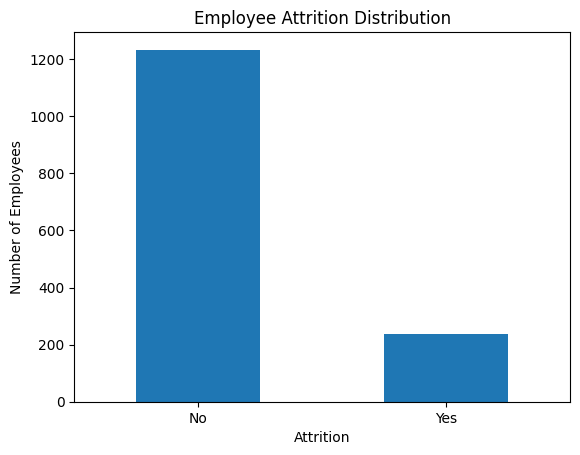

In [ ]:
import matplotlib.pyplot as plt

df["Attrition"].value_counts().plot(kind="bar")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


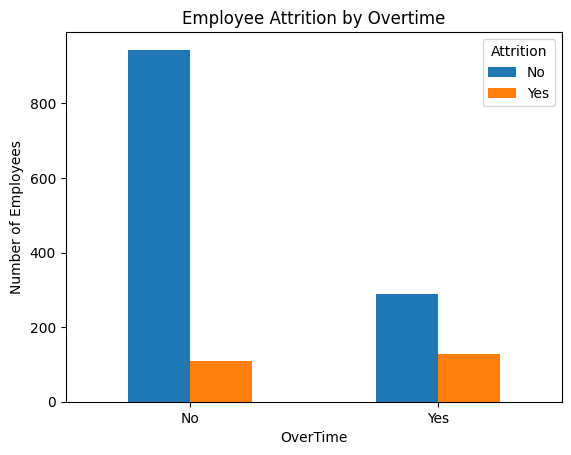

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"])

print(overtime_attrition)

overtime_attrition.plot(kind="bar")

plt.title("Employee Attrition by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.show()

Attrition                   No  Yes
JobRole                            
Healthcare Representative  122    9
Human Resources             40   12
Laboratory Technician      197   62
Manager                     97    5
Manufacturing Director     135   10
Research Director           78    2
Research Scientist         245   47
Sales Executive            269   57
Sales Representative        50   33


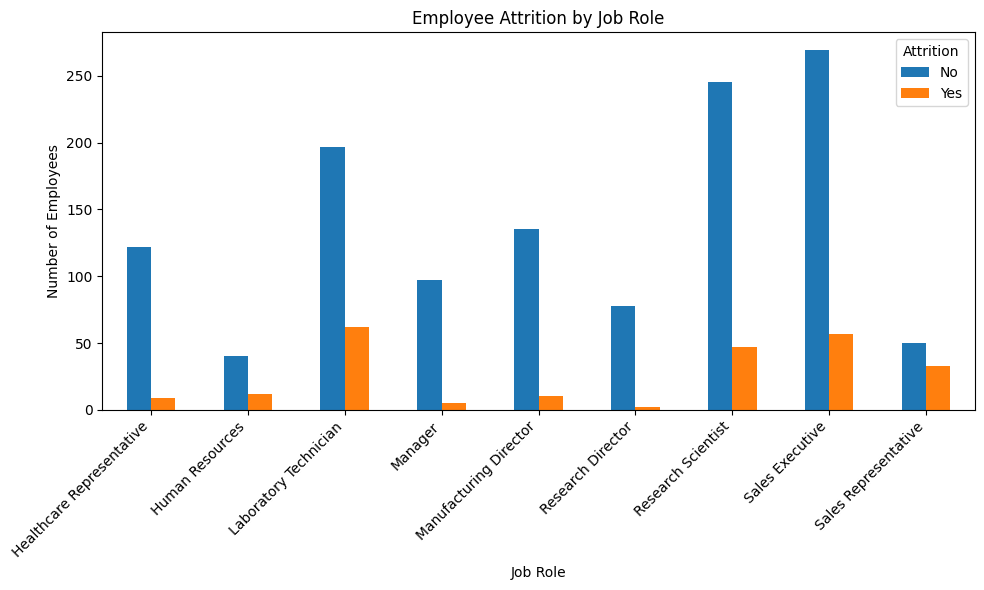

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

job_attrition = pd.crosstab(df["JobRole"], df["Attrition"])

print(job_attrition)

job_attrition.plot(kind="bar", figsize=(10, 6))

plt.title("Employee Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

Attrition         No  Yes
JobSatisfaction          
1                223   66
2                234   46
3                369   73
4                407   52


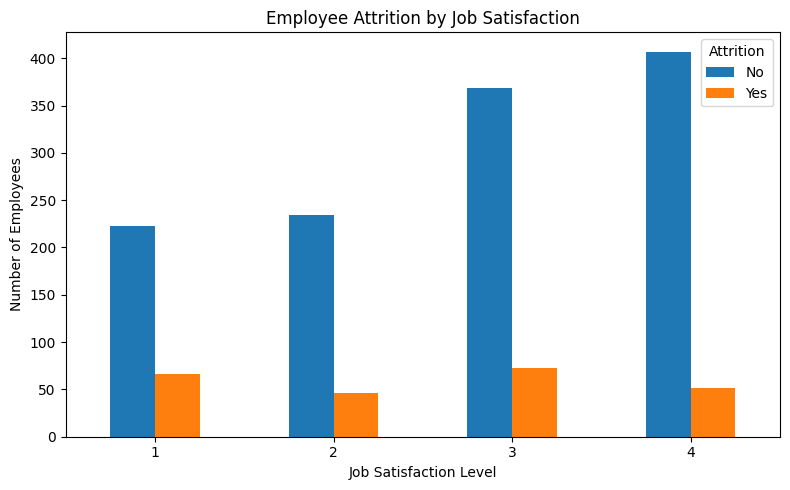

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

satisfaction_attrition = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"]
)

print(satisfaction_attrition)

satisfaction_attrition.plot(kind="bar", figsize=(8, 5))

plt.title("Employee Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

In [ ]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 34)
y shape: (1470,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 34)
Testing data: (294, 34)


In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:")
print(categorical_columns.tolist())

print("\nNumerical columns:")
print(numerical_columns.tolist())

Categorical columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred_lr[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("Accuracy:", accuracy_lr)
print("Recall:", recall_lr)
print("ROC-AUC:", roc_auc_lr)

Logistic Regression Results
Accuracy: 0.8605442176870748
Recall: 0.3404255319148936
ROC-AUC: 0.8106641398914636


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest predictions generated successfully!
First 10 predictions: [1 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("Accuracy:", accuracy_rf)
print("Recall:", recall_rf)
print("ROC-AUC:", roc_auc_rf)

Random Forest Results
Accuracy: 0.8469387755102041
Recall: 0.14893617021276595
ROC-AUC: 0.8120854509432336


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Recall": [recall_lr, recall_rf],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf]
})

results

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.860544,0.340426,0.810664
1,Random Forest,0.846939,0.148936,0.812085


Confusion Matrix:
[[237  10]
 [ 31  16]]


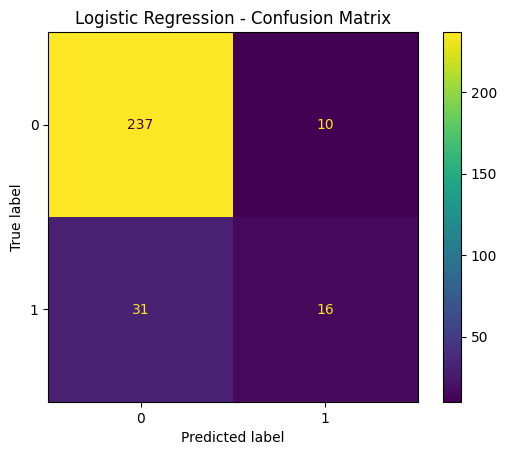

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

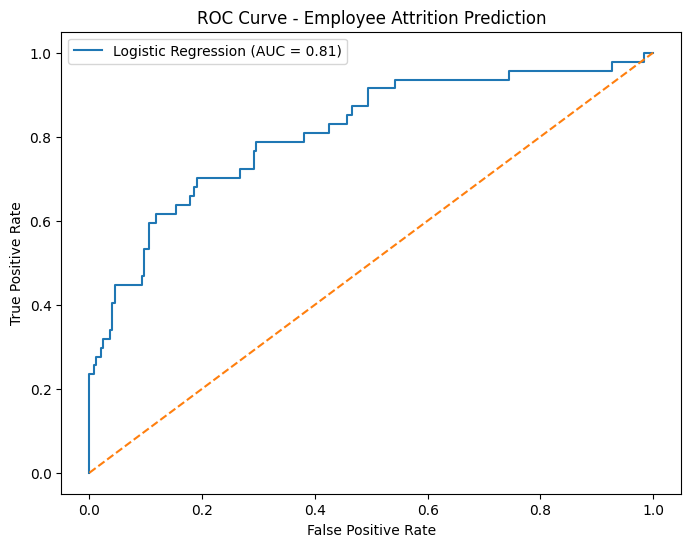

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Employee Attrition Prediction")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

rf_model = random_forest_model.named_steps["model"]
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Factors Affecting Employee Attrition:")
print(feature_importance.head(10))

Top 10 Factors Affecting Employee Attrition:
                      Feature  Importance
11         num__MonthlyIncome    0.066348
0                    num__Age    0.060360
19     num__TotalWorkingYears    0.054729
1              num__DailyRate    0.046978
7             num__HourlyRate    0.044487
12           num__MonthlyRate    0.044068
5         num__EmployeeNumber    0.043800
2       num__DistanceFromHome    0.042807
22        num__YearsAtCompany    0.040469
25  num__YearsWithCurrManager    0.036168
